"""
EXPLORATORY DATA ANALYSIS (EDA) FOR FINANCIAL REGIME CLASSIFICATION.\
\
Purpose: Understand data before building the pipeline.\
This is NOT part of the automated pipeline. its for your understanding of the data.
* Notebook: Understanding data, discovering patterns, deciding strategies
* Pipeline: Automated execution, reproducibility, production deployment
"""

In [ ]:
# cell 1
# imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
# cell 2
# load data
df = pd.read_csv("C:\\Users\\user\\OneDrive\\Desktop\\financial_regime_clasification\\data\\raw\\raw.csv")
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# cell 3
# basic info
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe)

Dataset shape: (2942, 17)

Columns: ['Unnamed: 0', 'date', 'open', 'high', 'low', 'close', 'volume', 'past_ret_1h', 'past_ret_2h', 'past_ret_4h', 'past_ret_8h', 'past_ret_16h', 'forward regime', 'probability', '0.6 percent prediction', '1 percent prediction', '1.5 percent prediction']

Data Types:
Unnamed: 0                         int64
date                      datetime64[ns]
open                             float64
high                             float64
low                              float64
close                            float64
volume                             int64
past_ret_1h                      float64
past_ret_2h                      float64
past_ret_4h                      float64
past_ret_8h                      float64
past_ret_16h                     float64
forward regime                    object
probability                      float64
0.6 percent prediction           float64
1 percent prediction             float64
1.5 percent prediction           float64
dtyp

In [ ]:
# cell 4
# missing values analysis
pred_cols = ['probability', '0.6 percent prediction', '1 percent prediction', '1.5 percent prediction']
missing_pct = df[pred_cols].isnull().mean() * 100
print("Missing percentages")
print(missing_pct)

Missing percentages
probability               31.815092
0.6 percent prediction    35.723997
1 percent prediction      35.723997
1.5 percent prediction    35.723997
dtype: float64


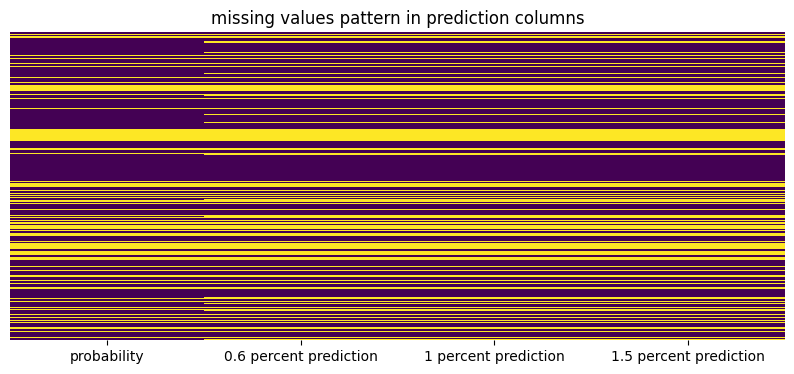

In [ ]:
# cell 5
# visualize missing pattern
plt.figure(figsize=(10,4))
sns.heatmap(df[pred_cols].isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('missing values pattern in prediction columns')
plt.show()

In [11]:
# cell 6
# target disturibution
print("\nTarget distributiion")
print(df['forward regime'].value_counts())
print(df['forward regime'].value_counts(normalize=True) * 100)


Target distributiion
forward regime
range       1946
upward       551
downward     445
Name: count, dtype: int64
forward regime
range       66.145479
upward      18.728756
downward    15.125765
Name: proportion, dtype: float64


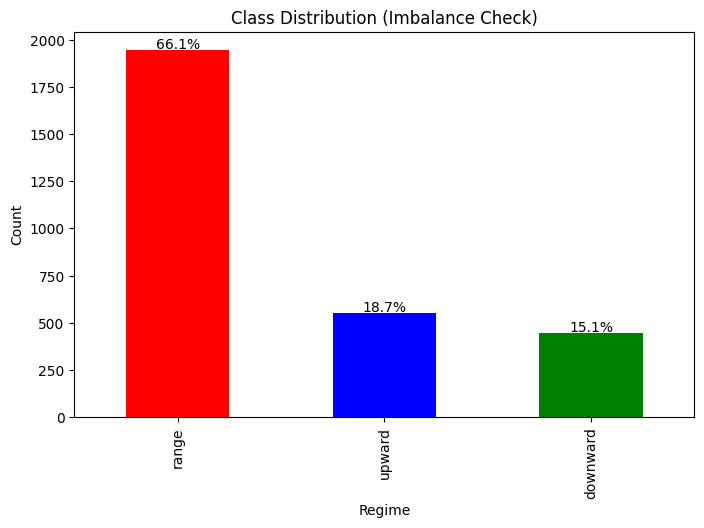

In [13]:
# cell 7
# plot class distribution
plt.figure(figsize=(8,5))
df['forward regime'].value_counts().plot(kind='bar', color=['red', 'blue', 'green'])
plt.title('Class Distribution (Imbalance Check)')
plt.xlabel('Regime')
plt.ylabel('Count')
# add percentage labels
for i, v in enumerate(df['forward regime'].value_counts().values):
    plt.text(i, v + 10, f'{v/len(df)*100:.1f}%', ha='center')
plt.show()

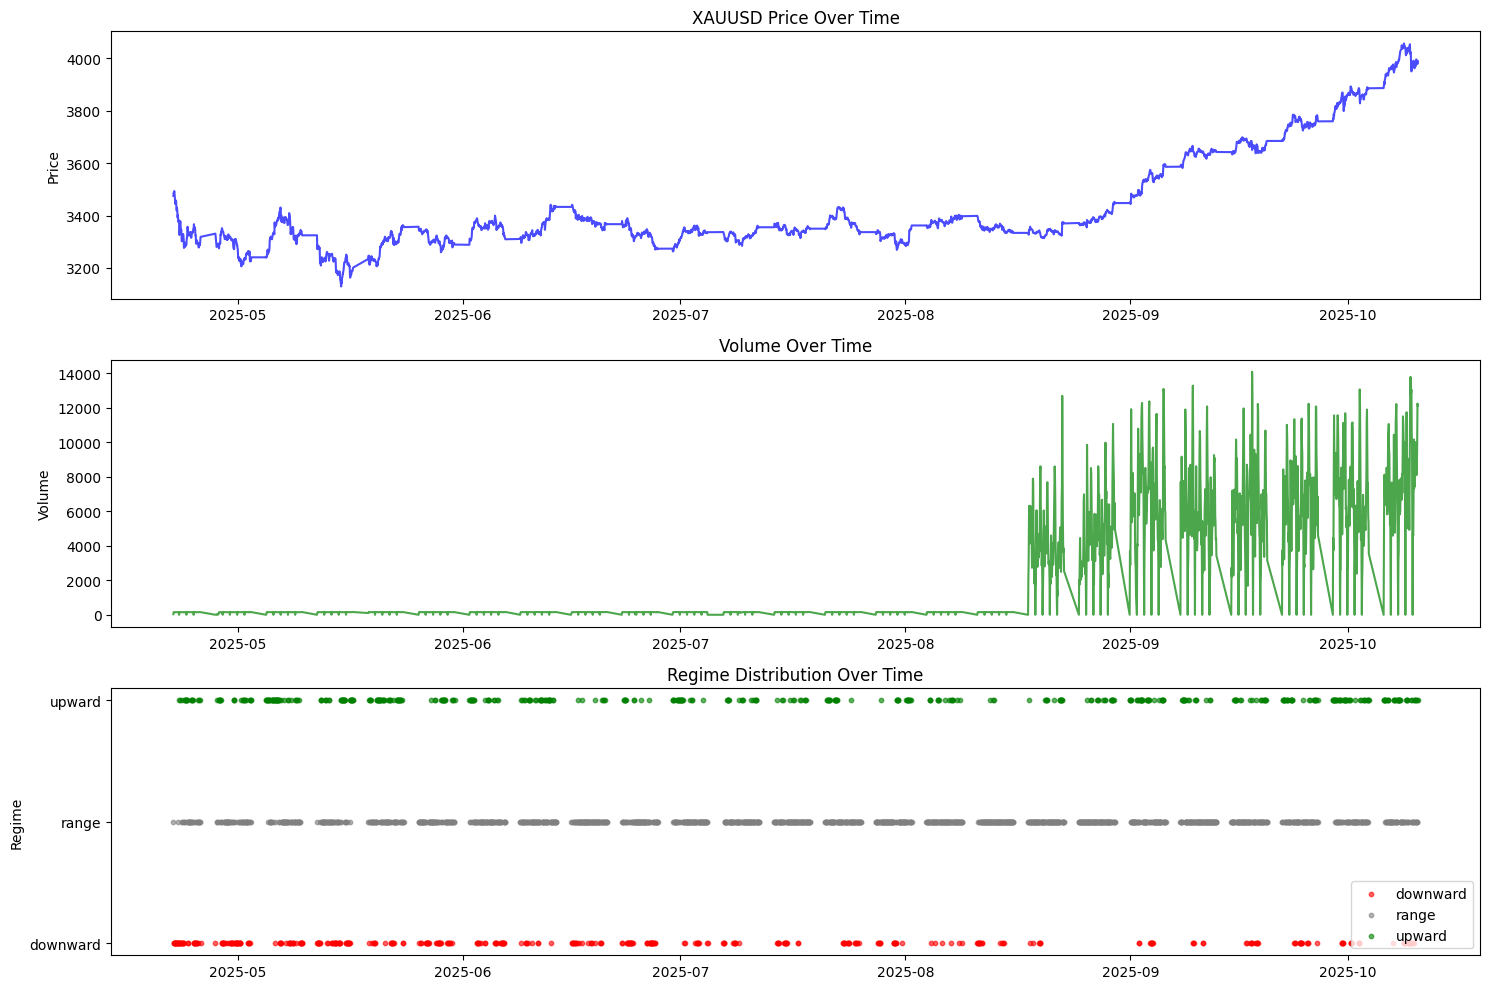

In [20]:
# cell 8
# time series visualization
fig, axes = plt.subplots(3, 1, figsize=(15,10))
# price
axes[0].plot(df['date'], df['close'], color='blue', alpha=0.7)
axes[0].set_title('XAUUSD Price Over Time')
axes[0].set_ylabel('Price')
# volume
axes[1].plot(df['date'], df['volume'], color='green', alpha=0.7)
axes[1].set_title('Volume Over Time')
axes[1].set_ylabel('Volume')
# target regimes (color-coded)
colors = {'downward': 'red', 'range': 'gray', 'upward': 'green'}
for regime, color in colors.items():
    mask = df['forward regime'] == regime
    axes[2].scatter(df[mask]['date'], [regime]*mask.sum(),
                    c=color, s=10, alpha=0.6, label=regime)
axes[2].set_title('Regime Distribution Over Time')
axes[2].set_ylabel('Regime')
axes[2].legend()

plt.tight_layout()
plt.show()

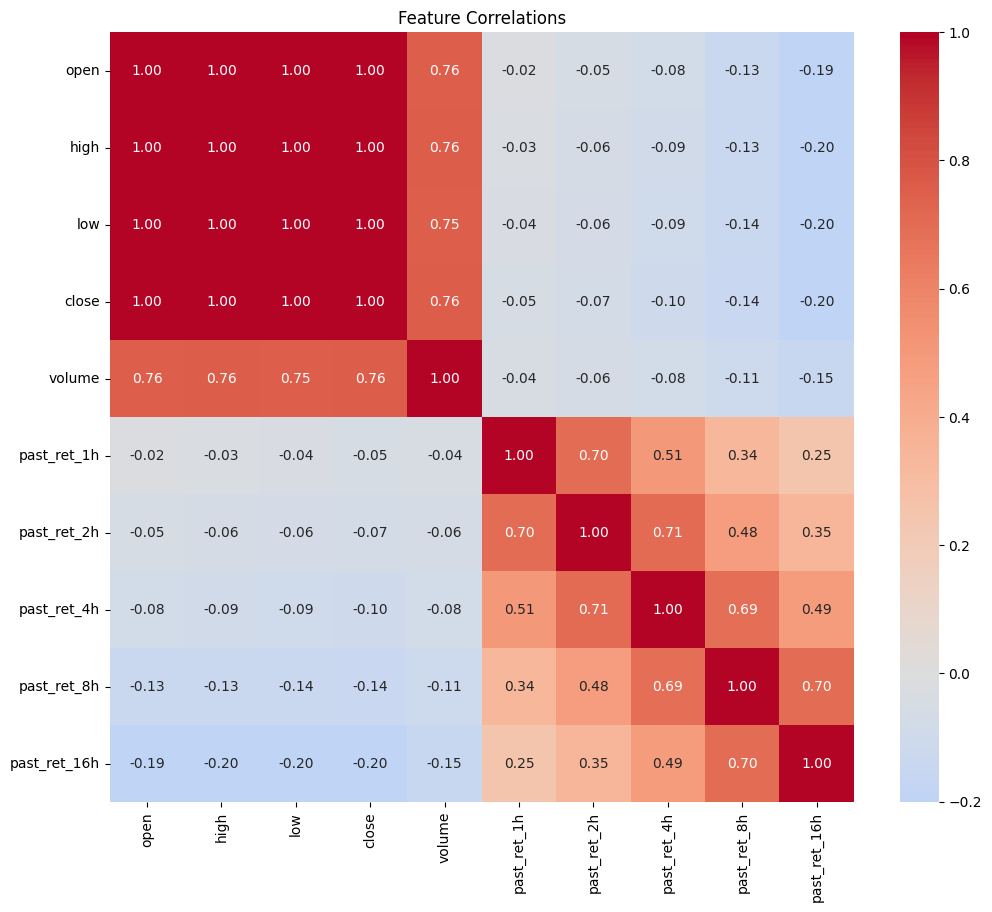

In [21]:
# cell 9
# feature correlations
feature_cols = ['open', 'high', 'low', 'close', 'volume',
                'past_ret_1h', 'past_ret_2h', 'past_ret_4h',
                'past_ret_8h', 'past_ret_16h']
corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Feature Correlations")
plt.show()

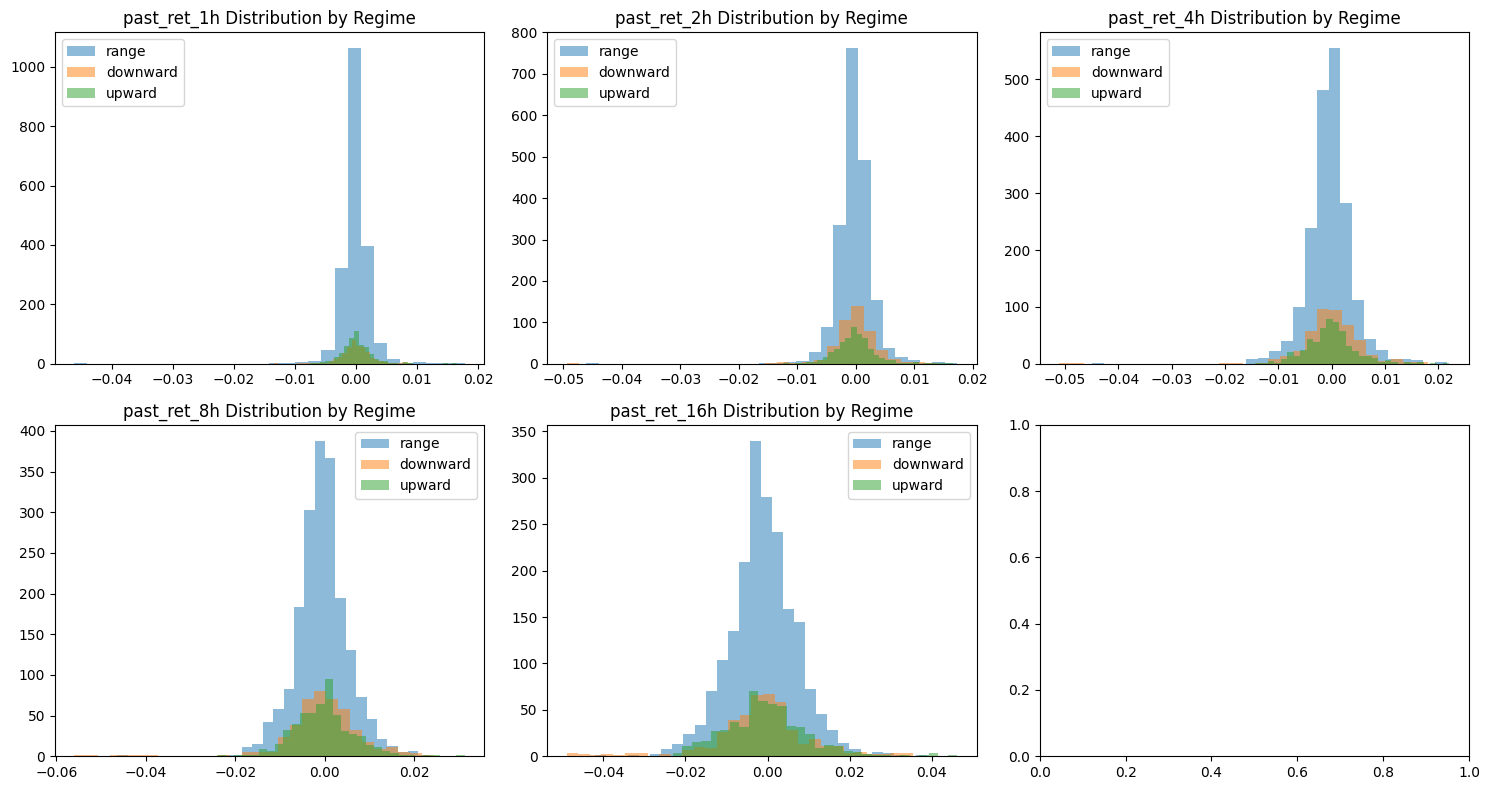

In [22]:
# cell 10
# past returns by regime
ret_cols = ['past_ret_1h', 'past_ret_2h', 'past_ret_4h', 'past_ret_8h', 'past_ret_16h']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(ret_cols):
    for regime in df['forward regime'].unique():
        data = df[df['forward regime'] == regime][col].dropna()
        axes[i].hist(data, bins=30, alpha=0.5, label=regime)
    axes[i].set_title(f'{col} Distribution by Regime')
    axes[i].legend()
plt.tight_layout()
plt.show()

In [23]:
# cell 11
# summart statistics by regime
print("\nFeature means by regime:")
for regime in df['forward regime'].unique():
    print(f"\n{regime.upper()}:")
    regime_data = df[df['forward regime'] == regime]
    for col in ret_cols:
        print(f" {col}: {regime_data[col].mean():.6f} (+- {regime_data[col].std():.6f})")


Feature means by regime:

RANGE:
 past_ret_1h: -0.000120 (+- 0.002319)
 past_ret_2h: -0.000187 (+- 0.003014)
 past_ret_4h: -0.000338 (+- 0.004167)
 past_ret_8h: -0.000583 (+- 0.005800)
 past_ret_16h: -0.001027 (+- 0.008231)

DOWNWARD:
 past_ret_1h: 0.000043 (+- 0.002482)
 past_ret_2h: 0.000037 (+- 0.004192)
 past_ret_4h: -0.000213 (+- 0.006422)
 past_ret_8h: -0.000346 (+- 0.009171)
 past_ret_16h: -0.001260 (+- 0.011868)

UPWARD:
 past_ret_1h: 0.000069 (+- 0.002575)
 past_ret_2h: -0.000007 (+- 0.003663)
 past_ret_4h: 0.000094 (+- 0.005018)
 past_ret_8h: -0.000242 (+- 0.006741)
 past_ret_16h: -0.000413 (+- 0.010134)


In [24]:
# cell 12
# check for data leakage (future information)
print("\nChecking potential data leakage...")
print(f"Earliest date: {df['date'].min()}")
print(f"Latest date: {df['date'].max()}")
print(f"Total time span: {df['date'].max() - df['date'].min()}")


Checking potential data leakage...
Earliest date: 2025-04-22 03:00:00
Latest date: 2025-10-10 15:00:00
Total time span: 171 days 12:00:00


In [ ]:
# cell 13
# check if prediction columns contain future information
if 'probability' in df.columns:
    print("\nChecking if probability correlates with future returns...")
    df['future_1h_reutrn'] = df['close'].shift(-1) / df['close'] - 1
    correlation = df['probability'].corr(df['future_1h_reutrn'])
    print(f"Correlation between probability and next hour {correlation:.3f}")

    if abs(correlation) > 0.5:
        print("Warning: high correlation detected - potential of data leackage")



Checking if probability correlates with future returns...
Correlation between probability and next hour 0.002


In [26]:
# cell 14
# save EDA Summary
summary = {
    'total_rows': len(df),
    'total_columns': len(df.columns),
    'missing_percentage': missing_pct.mean(),
    'class_distribuiton': df['forward regime'].value_counts().to_dict(),
    'data_range': f"{df['date'].min()} to {df['date'].max()}"
}

print("\nEDA Summary:")
for key, value in summary.items():
    print(f" {key}: {value}")


EDA Summary:
 total_rows: 2942
 total_columns: 18
 missing_percentage: 34.746770904146835
 class_distribuiton: {'range': 1946, 'upward': 551, 'downward': 445}
 data_range: 2025-04-22 03:00:00 to 2025-10-10 15:00:00
